# StreetForward 演示 Notebook

本 notebook 展示 StreetForward 训练器的基本功能和训练过程。

## 功能概述

### StreetForward
1. Feed-forward 3DGS 训练器，基于代理参数的多视角梯度累积
2. 使用 node_state 作为 detached buffer 存储 Gaussian 参数
3. 通过 MLP 预测偏移量，而不是直接预测参数
4. 使用 Proxy 参数进行渲染，避免二次反传共享图问题
5. 支持多视角监督和梯度回灌机制
6. **新增**：支持测试视角评估（PSNR、SSIM、LPIPS）
7. **新增**：增强的偏移量控制（位置、尺度、旋转、不透明度、SH）
8. **新增**：训练/测试帧分离支持

### 本 Notebook 包含
1. MultiSceneDataset 数据加载（集成点云生成）
2. Batch 格式转换（MultiSceneDataset → StreetForward）
3. StreetForwardTrainer 初始化和训练
4. 训练循环演示
5. **测试视角和评估指标演示**（新增）
6. 结果可视化

## 使用说明

1. 按顺序执行所有单元格
2. 在"配置准备"部分修改配置文件路径（如果需要）
3. 每个部分可以独立运行和调试
4. 注意内存使用，特别是点云生成和训练部分
5. **测试视角评估**：需要配置 `test_image_stride` 和 `max_test_images` 才能使用

## 更新说明

本 notebook 已更新以使用新的重构实现：
- 使用 `configs/streetforward/multi_scene.yaml` 配置文件
- `MultiSceneDataset` 已集成点云生成功能
- `get_segment_batch()` 自动生成点云并包含在 batch 中
- **新增**：支持测试视角加载和评估（`include_test=True`）
- **新增**：评估指标计算（PSNR、SSIM、LPIPS）
- **新增**：增强的模型配置参数（offset_max, scale_max, omega_max 等）

## 第一部分：环境配置和导入

安装和导入所有必要的依赖包。

In [1]:
# 安装依赖（如果需要）
# !pip install numpy matplotlib open3d omegaconf torch

# 自动加载更改的魔法指令（在开发过程中自动重新加载模块）
%load_ext autoreload
%autoreload 2

import os
import sys
import numpy as np
import torch
import types
from omegaconf import OmegaConf
from typing import List, Dict, Optional
import matplotlib.pyplot as plt
import open3d as o3d

# 添加项目路径以导入模块
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, project_root)

# 导入项目模块
from datasets.multi_scene_dataset import MultiSceneDataset, MultiSceneDatasetScheduler
from models.trainers.streetforward import StreetForwardTrainer
from tools.train_streetforward import convert_batch_to_streetforward_format

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 设置随机种子（可选，用于可重复性）
torch.manual_seed(42)
np.random.seed(42)

print("Environment setup completed!")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/root/miniconda3/envs/drivestudio-new/lib/python3.9/site-packages/torchmetrics/utilities/imports.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.0+cu118
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Using device: cuda
Environment setup completed!


## 第二部分：配置准备

读取配置文件，准备数据配置和 StreetForward 训练器配置。

In [ ]:
# 读取配置文件（StreetForward 配置）
config_path = os.path.join(project_root, "configs/streetforward/multi_scene.yaml")
cfg = OmegaConf.load(config_path)

# 提取数据配置
data_cfg = cfg.data

# 提取 MultiSceneDataset 配置（现在在 dataset 下）
dataset_cfg = cfg.dataset


# 显示配置信息
print("Data configuration:")
print(f"  Data root: {data_cfg.data_root}")
print(f"  Dataset type: {data_cfg.dataset}")
print(f"  Train scene IDs: {data_cfg.train_scene_ids}")
print(f"  Eval scene IDs: {data_cfg.eval_scene_ids}")

# 显示测试帧配置（如果存在）
pixel_source_cfg = getattr(data_cfg, "pixel_source", {})
if pixel_source_cfg:
    test_image_stride = pixel_source_cfg.get("test_image_stride", 0)
    max_test_images = pixel_source_cfg.get("max_test_images", 0)
    print(f"  Test image stride: {test_image_stride} (0 = all frames for training)")
    print(f"  Max test images per segment: {max_test_images} (0 = all available)")

print("\nMultiSceneDataset configuration:")
print(f"  Num source keyframes: {dataset_cfg.num_source_keyframes}")
print(f"  Num target keyframes: {dataset_cfg.num_target_keyframes}")
print(f"  Segment overlap ratio: {dataset_cfg.segment_overlap_ratio}")
print(f"  Min keyframes per scene: {dataset_cfg.min_keyframes_per_scene}")
print(f"  Min keyframes per segment: {dataset_cfg.min_keyframes_per_segment}")

# 显示 pointcloud 配置（现在在 dataset.pointcloud 下）
if hasattr(dataset_cfg, 'pointcloud') and dataset_cfg.pointcloud is not None:
    print("\nPoint cloud configuration:")
    print(f"  Type: {dataset_cfg.pointcloud.get('type', 'N/A')}")
    print(f"  Chosen cam IDs: {dataset_cfg.pointcloud.get('chosen_cam_ids', 'N/A')}")
    print(f"  Sparsity: {dataset_cfg.pointcloud.get('sparsity', 'N/A')}")
    print(f"  Filter sky: {dataset_cfg.pointcloud.get('filter_sky', 'N/A')}")
    print(f"  Depth consistency: {dataset_cfg.pointcloud.get('depth_consistency', 'N/A')}")
    print(f"  Use bounding box: {dataset_cfg.pointcloud.get('use_bbx', 'N/A')}")
    print(f"  Downscale: {dataset_cfg.pointcloud.get('downscale', 'N/A')}")

# 准备 fixed_segment_aabb（如果配置了）
fixed_segment_aabb = None
if dataset_cfg.get('fixed_segment_aabb') is not None:
    fixed_segment_aabb = torch.tensor(dataset_cfg.fixed_segment_aabb, dtype=torch.float32)
    print(f"\nUsing fixed segment AABB: {fixed_segment_aabb}")

Data configuration:
  Data root: /root/autodl-tmp/nuScenes/
  Dataset type: nuscenes
  Train scene IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Eval scene IDs: [10, 11, 12, 13]
  Test image stride: 0 (0 = all frames for training)
  Max test images per segment: 4 (0 = all available)

MultiSceneDataset configuration:
  Num source keyframes: 3
  Num target keyframes: 6
  Segment overlap ratio: 0.2
  Min keyframes per scene: 10
  Min keyframes per segment: 6

Point cloud configuration:
  Type: monocular
  Chosen cam IDs: [0, 1, 2]
  Sparsity: full
  Filter sky: True
  Depth consistency: True
  Use bounding box: True
  Downscale: 2

Using fixed segment AABB: tensor([[-20.0000, -20.0000, -20.0000],
        [ 20.0000,   4.8000,  70.0000]])


In [3]:
# 创建 StreetForward 训练器配置
# 参考 tests/test_streetforward.py 和模型设计文档

# 从 segment AABB 获取 bbx_min 和 bbx_max（如果有固定AABB）
if fixed_segment_aabb is not None:
    bbx_min = fixed_segment_aabb[0].tolist()
    bbx_max = fixed_segment_aabb[1].tolist()
else:
    # 使用默认值（可以从配置文件中读取）
    bbx_min = [-20.0, -20.0, -20.0]
    bbx_max = [20.0, 4.8, 70.0]

# 从配置文件读取模型参数（如果存在）
model_cfg = cfg.get("model", {})
streetforward_config = cfg
print("StreetForward configuration:")
print(f"  SparseConv output dim: {streetforward_config.model.sparseConv_outdim}")
print(f"  Offset max: {streetforward_config.model.offset_max}")
print(f"  Scale max: {streetforward_config.model.scale_max}")
print(f"  Omega max: {streetforward_config.model.omega_max}")
print(f"  Opacity max: {streetforward_config.model.opacity_max}")
print(f"  SH DC max: {streetforward_config.model.sh_dc_max}")
print(f"  SH rest max: {streetforward_config.model.sh_rest_max}")
print(f"  Eta (step size factors): means={streetforward_config.model.eta_means}, scales={streetforward_config.model.eta_scales}, opacity={streetforward_config.model.eta_opacity}")
print(f"  SH degree: {streetforward_config.model.sh_degree}")
print(f"  Voxel size: {streetforward_config.model.voxel_size}")
print(f"  Max iterations: {streetforward_config.model.max_iterations}")
print(f"  Bounding box min: {streetforward_config.model.bbx_min}")
print(f"  Bounding box max: {streetforward_config.model.bbx_max}")
print(f"  Learning rate: {streetforward_config.optimizer.lr}")

StreetForward configuration:
  SparseConv output dim: 32
  Offset max: 0.1
  Scale max: 0.1
  Omega max: 0.1
  Opacity max: 0.1
  SH DC max: 0.1
  SH rest max: 0.05
  Eta (step size factors): means=1.0, scales=1.0, opacity=1.0
  SH degree: 1
  Voxel size: 0.1
  Max iterations: 1
  Bounding box min: [-20.0, -20.0, -20.0]
  Bounding box max: [20.0, 4.8, 70.0]
  Learning rate: 0.001


## 第三部分：MultiSceneDataset 初始化

创建 MultiSceneDataset 实例并初始化数据集。

In [4]:
# 准备 pointcloud 配置（从 dataset_cfg.pointcloud 读取）
pointcloud_config = None
if hasattr(dataset_cfg, 'pointcloud') and dataset_cfg.pointcloud is not None:
    pointcloud_config = dict(dataset_cfg.pointcloud)
    print("Pointcloud configuration prepared from dataset_cfg.pointcloud")
else:
    print("Warning: No pointcloud config found. Pointcloud will not be generated automatically.")

# 创建 MultiSceneDataset 实例（现在会自动创建 pointcloud_generator）
dataset = MultiSceneDataset(
    data_cfg=data_cfg,
    train_scene_ids=data_cfg.train_scene_ids,
    eval_scene_ids=data_cfg.eval_scene_ids,
    num_source_keyframes=dataset_cfg.num_source_keyframes,
    num_target_keyframes=dataset_cfg.num_target_keyframes,
    segment_overlap_ratio=dataset_cfg.segment_overlap_ratio,
    keyframe_split_config=dict(dataset_cfg.keyframe_split_config) if hasattr(dataset_cfg, 'keyframe_split_config') else None,
    min_keyframes_per_scene=dataset_cfg.min_keyframes_per_scene,
    min_keyframes_per_segment=dataset_cfg.min_keyframes_per_segment,
    device=device,
    preload_scene_count=2,  # 预加载2个场景（减少内存占用）
    fixed_segment_aabb=fixed_segment_aabb,
    pointcloud_config=pointcloud_config,  # 传入 pointcloud 配置（注意参数名是 pointcloud_config）
)

print("MultiSceneDataset created successfully!")
if dataset.pointcloud_generator is not None:
    print("  Pointcloud generator initialized automatically")
else:
    print("  Warning: No pointcloud generator initialized")

Pointcloud configuration prepared from dataset_cfg.pointcloud
MultiSceneDataset created successfully!
  Pointcloud generator initialized automatically


In [5]:
# 初始化数据集（可选，会在第一次使用时自动初始化）
dataset.initialize()

# 获取当前场景ID
current_scene_id = dataset.get_current_scene_id()
print(f"Current training scene ID: {current_scene_id}")

# 获取场景信息（如果场景已加载）
if current_scene_id is not None:
    scene_info = dataset.get_scene(current_scene_id)
    if scene_info:
        print(f"\nScene {current_scene_id} information:")
        print(f"  Number of segments: {len(scene_info['segments'])}")
        print(f"  Number of frames: {scene_info['num_frames']}")
        print(f"  Number of cameras: {scene_info['num_cams']}")
        print(f"  Number of keyframe segments: {len(scene_info['keyframe_segments'])}")
        
        # 显示训练帧和测试帧信息（如果可用）
        if 'train_frame_indices' in scene_info and 'test_frame_indices' in scene_info:
            train_frames = scene_info['train_frame_indices']
            test_frames = scene_info['test_frame_indices']
            print(f"  Training frames: {len(train_frames)} frames")
            print(f"  Test frames: {len(test_frames)} frames")
            if len(test_frames) > 0:
                print(f"    Test frame indices (first 10): {test_frames[:10]}")
        
        # 显示每个段的信息
        for i, segment in enumerate(scene_info['segments']):
            print(f"\n  Segment {i}:")
            print(f"    Keyframe indices: {segment['keyframe_indices']}")
            print(f"    Number of frames: {len(segment['frame_indices'])}")
            print(f"    AABB shape: {segment['aabb'].shape}")
            # 显示段内的测试帧（如果可用）
            if 'test_frame_indices' in segment:
                test_frames_in_seg = segment['test_frame_indices']
                print(f"    Test frames in segment: {len(test_frames_in_seg)}")
                if len(test_frames_in_seg) > 0:
                    print(f"      Test frame indices: {test_frames_in_seg[:10]}{'...' if len(test_frames_in_seg) > 10 else ''}")

Loading images:   0%|          | 0/196 [00:00<?, ?it/s]

Loading lidar: 100%|██████████| 196/196 [00:01<00:00, 152.89it/s]
Projecting lidar pts on images for camera CAM_FRONT: 100%|██████████| 196/196 [00:03<00:00, 58.18it/s]
Projecting lidar pts on images for camera CAM_FRONT_LEFT: 100%|██████████| 196/196 [00:03<00:00, 62.56it/s]
Projecting lidar pts on images for camera CAM_FRONT_RIGHT: 100%|██████████| 196/196 [00:03<00:00, 63.39it/s]
Loading lidar: 100%|██████████| 191/191 [00:01<00:00, 149.82it/s]
Projecting lidar pts on images for camera CAM_FRONT: 100%|██████████| 191/191 [00:04<00:00, 43.64it/s]
Projecting lidar pts on images for camera CAM_FRONT_LEFT: 100%|██████████| 191/191 [00:04<00:00, 44.12it/s]
Projecting lidar pts on images for camera CAM_FRONT_RIGHT: 100%|██████████| 191/191 [00:04<00:00, 44.48it/s]
Loading lidar: 100%|██████████| 196/196 [00:01<00:00, 161.74it/s]
Projecting lidar pts on images for camera CAM_FRONT: 100%|██████████| 196/196 [00:04<00:00, 43.62it/s]
Projecting lidar pts on images for camera CAM_FRONT_LEFT: 1

Current training scene ID: 8

Scene 8 information:
  Number of segments: 13
  Number of frames: 196
  Number of cameras: 3
  Number of keyframe segments: 70
  Training frames: 196 frames
  Test frames: 196 frames
    Test frame indices (first 10): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

  Segment 0:
    Keyframe indices: [0, 1, 2, 3, 4, 5]
    Number of frames: 18
    AABB shape: torch.Size([2, 3])
    Test frames in segment: 18
      Test frame indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...

  Segment 1:
    Keyframe indices: [5, 6, 7, 8, 9, 10]
    Number of frames: 17
    AABB shape: torch.Size([2, 3])
    Test frames in segment: 17
      Test frame indices: [15, 16, 17, 18, 19, 20, 21, 22, 23, 24]...

  Segment 2:
    Keyframe indices: [10, 11, 12, 13, 14, 15, 16]
    Number of frames: 21
    AABB shape: torch.Size([2, 3])
    Test frames in segment: 21
      Test frame indices: [29, 30, 31, 32, 33, 34, 35, 36, 37, 38]...

  Segment 3:
    Keyframe indices: [15, 16, 17, 18, 19, 20, 21]
    Num

## 第六部分：StreetForwardTrainer 初始化

创建 StreetForwardTrainer 实例并展示模型结构。

In [6]:
# 创建 StreetForwardTrainer 实例
trainer = StreetForwardTrainer(
    config=streetforward_config,
    device=device,
)

print("StreetForwardTrainer created successfully!")
print(f"\nModel structure:")
print(f"  SparseConv: {type(trainer.sparse_conv).__name__}")
print(f"  MLP Offset Position: {trainer.mlp_offset_pos}")
print(f"  MLP Conv (scales + axis-angle): {trainer.mlp_conv}")
print(f"    Note: Now outputs 6 dims (3 for scales + 3 for axis-angle) instead of 7")
print(f"  MLP Opacity: {trainer.mlp_opacity}")
print(f"  Gaussian Decoder (SH): {trainer.gaussion_decoder}")

# 计算参数量
total_params = sum(p.numel() for p in trainer.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

# 显示优化器配置
print(f"\nOptimizer:")
print(f"  Type: {type(trainer.optimizer).__name__}")
print(f"  Learning rate: {trainer.optimizer.param_groups[0]['lr']}")
print(f"  Eps: {trainer.optimizer.param_groups[0]['eps']}")
print(f"  Weight decay: {trainer.optimizer.param_groups[0]['weight_decay']}")

# 检查节点状态字典（初始为空）
print(f"\nNode states (initial): {len(trainer.node_states)} nodes")

StreetForwardTrainer created successfully!

Model structure:
  SparseConv: SparseCostRegNet
  MLP Offset Position: Sequential(
  (0): Linear(in_features=32, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=3, bias=True)
)
  MLP Conv (scales + axis-angle): Sequential(
  (0): Linear(in_features=32, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=6, bias=True)
)
    Note: Now outputs 6 dims (3 for scales + 3 for axis-angle) instead of 7
  MLP Opacity: Sequential(
  (0): Linear(in_features=32, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)
  Gaussian Decoder (SH): Sequential(
  (0): Linear(in_features=32, out_features=64, bias=True)
  (1): ReLU()
  (2):

## 第七部分：单个 Batch 训练演示

获取一个 batch，生成点云，转换格式，运行 train_iter()。

In [7]:
# 获取一个 batch（从 MultiSceneDataset）
# 注意：get_segment_batch() 现在自动生成点云并包含在 batch 中
scene_id = dataset.get_current_scene_id()
if scene_id is None:
    print("No scene available. Please check dataset initialization.")
else:
    scene_info = dataset.get_scene(scene_id)
    if scene_info and len(scene_info['segments']) > 0:
        segment_id = 0
        
        print(f"Getting batch for scene {scene_id}, segment {segment_id}...")
        multi_scene_batch = dataset.get_segment_batch(scene_id=scene_id, segment_id=segment_id)
        
        print(f"\nMultiSceneDataset batch structure:")
        print(f"  Scene ID: {multi_scene_batch['scene_id']}")
        print(f"  Segment ID: {multi_scene_batch['segment_id']}")
        print(f"  Source images shape: {multi_scene_batch['source']['image'].shape}")
        print(f"  Target images shape: {multi_scene_batch['target']['image'].shape}")
        print(f"  Target extrinsics shape: {multi_scene_batch['target']['extrinsics'].shape}")
        print(f"  Target intrinsics shape: {multi_scene_batch['target']['intrinsics'].shape}")
        
        # 检查点云是否已在 batch 中
        if 'pointcloud' in multi_scene_batch:
            pointcloud_dict = multi_scene_batch['pointcloud']
            background_points = pointcloud_dict.get("background", np.zeros((0, 6), dtype=np.float32))
            print(f"\nPoint cloud (automatically generated):")
            print(f"  Background points shape: {background_points.shape}")
        else:
            print("\nWarning: No pointcloud in batch. Pointcloud generation may have failed.")
            pointcloud_dict = None
        
        # 转换 batch 格式（点云已包含在 batch 中）
        print(f"\nConverting batch format...")
        if pointcloud_dict is not None:
            streetforward_batch = convert_batch_to_streetforward_format(
                batch=multi_scene_batch,
                device=device,
            )
            
            print(f"\nStreetForward batch structure:")
            print(f"  Scene ID: {streetforward_batch['scene_id']}")
            print(f"  Segment ID: {streetforward_batch['segment_id']}")
            print(f"  Pointcloud background shape: {streetforward_batch['pointcloud']['background'].shape}")
            print(f"  Number of target views: {len(streetforward_batch['target_views'])}")
            print(f"  Number of GT images: {len(streetforward_batch['gt_images'])}")
            if len(streetforward_batch['gt_images']) > 0:
                print(f"  GT image shape: {streetforward_batch['gt_images'][0].shape}")
        else:
            print("Cannot convert batch - pointcloud is missing.")
            streetforward_batch = None
    else:
        print("No segments available in current scene.")
        streetforward_batch = None

Getting batch for scene 8, segment 0...

MultiSceneDataset batch structure:
  Scene ID: tensor([8])
  Segment ID: 0
  Source images shape: torch.Size([9, 300, 533, 3])
  Target images shape: torch.Size([18, 300, 533, 3])
  Target extrinsics shape: torch.Size([18, 4, 4])
  Target intrinsics shape: torch.Size([18, 4, 4])

Point cloud (automatically generated):
  Background points shape: (761200, 6)

Converting batch format...

StreetForward batch structure:
  Scene ID: tensor([8], device='cuda:0')
  Segment ID: tensor([0], device='cuda:0')
  Pointcloud background shape: (761200, 6)
  Number of target views: 18
  Number of GT images: 18
  GT image shape: torch.Size([300, 533, 3])


In [8]:
# 运行 train_iter()（不更新状态，仅演示）
if 'streetforward_batch' in locals() and streetforward_batch is not None:
    print("Running train_iter() (without update)...")
    
    # 运行一次迭代（不更新状态，仅演示前向传播和损失计算）
    # 注意：虽然 apply_update=False 和 update_state=False，但仍需要梯度来计算损失
    try:
        outputs = trainer.train_iter(
            batch=streetforward_batch,
            apply_update=False,  # 不更新优化器
            update_state=False,  # 不更新 node_state
        )
        
        print(f"\nTrain iteration completed!")
        print(f"  Total loss: {outputs['total_loss'].item():.6f}")
        print(f"  Number of outputs: {len(outputs['outputs'])}")
        
        if len(outputs['outputs']) > 0:
            print(f"\n  First output:")
            first_output = outputs['outputs'][0]
            if 'loss' in first_output:
                print(f"    Loss: {first_output['loss']:.6f}")
            if 'rgb' in first_output:
                print(f"    RGB shape: {first_output['rgb'].shape}")
            if 'acc' in first_output:
                print(f"    Accumulation shape: {first_output['acc'].shape}")
        
        # 检查节点状态（应该已创建）
        key = (streetforward_batch['scene_id'], streetforward_batch['segment_id'])
        if key in trainer.node_states:
            node_state = trainer.node_states[key]
            print(f"\n  Node state (scene {streetforward_batch['scene_id']}, segment {streetforward_batch['segment_id']}):")
            print(f"    Means shape: {node_state.means.shape}")
            print(f"    Scales log shape: {node_state.scales_log.shape}")
            print(f"    Quats shape: {node_state.quats.shape}")
            print(f"    Opacity logit shape: {node_state.opacity_logit.shape}")
            print(f"    SH DC shape: {node_state.sh_dc.shape}")
            print(f"    SH rest shape: {node_state.sh_rest.shape}")
        
    except Exception as e:
        print(f"Error during train_iter: {e}")
        import traceback
        traceback.print_exc()
else:
    print("No batch available. Please run the previous cell first.")

Running train_iter() (without update)...

Train iteration completed!
  Total loss: 0.194588
  Number of outputs: 18

  First output:
    Loss: 0.012334


## 第八部分：训练循环演示

使用调度器进行简化的训练循环，展示损失变化。

In [9]:
# 创建调度器
# 注意：可以设置 include_test=True 来在训练时包含测试视角（用于评估）
scheduler = dataset.create_scheduler(
    batches_per_segment=5,  # 每个段遍历5次（演示用，实际训练可以更多）
    segment_order="random",
    scene_order="random",
    shuffle_segments=True,
    preload_next_scene=True,
    include_test=True,  # 设置为 True 可以在训练时包含测试视角
)

print("Scheduler created successfully!")
print(f"  Batches per segment: 5")
print(f"  Segment order: random")
print(f"  Scene order: random")
print(f"  Include test views: False (set to True to include test views in batches)")

Scheduler created successfully!
  Batches per segment: 5
  Segment order: random
  Scene order: random
  Include test views: False (set to True to include test views in batches)


In [13]:
# 简化的训练循环（少量迭代，仅演示）
num_iterations = 3  # 演示用，只运行3次迭代

losses = []
scene_ids_list = []
segment_ids_list = []

print(f"Starting training loop ({num_iterations} iterations)...")
print("-" * 80)

try:
    for iteration in range(num_iterations):
        # 获取下一个 batch
        try:
            multi_scene_batch = scheduler.next_batch()
        except StopIteration:
            print("All scenes processed. Resetting scheduler...")
            scheduler.reset()
            multi_scene_batch = scheduler.next_batch()
        
        scene_id = multi_scene_batch['scene_id'].item() if isinstance(multi_scene_batch['scene_id'], torch.Tensor) else multi_scene_batch['scene_id']
        segment_id = multi_scene_batch['segment_id']
        
        # 获取当前状态信息
        info = scheduler.get_current_info()
        
        print(f"\nIteration {iteration + 1}/{num_iterations}:")
        print(f"  Scene ID: {scene_id}, Segment ID: {segment_id}")
        print(f"  Batch count: {info['batch_count']}/{info['batches_per_segment']}")
        
        # 注意：点云已经在 batch 中（get_segment_batch 自动生成）
        # 检查点云是否存在且不为空
        if 'pointcloud' not in multi_scene_batch:
            print("  Warning: No pointcloud in batch. Skipping this iteration.")
            continue
        
        # 检查点云是否为空
        pointcloud = multi_scene_batch['pointcloud']
        if isinstance(pointcloud, dict):
            background = pointcloud.get("background", np.zeros((0, 6), dtype=np.float32))
            if len(background) == 0:
                print(f"  Warning: Empty pointcloud for scene {scene_id}, segment {segment_id}. Skipping this iteration.")
                print(f"    This may happen if all points were filtered out (depth consistency, sky filtering, bbox cropping, etc.)")
                continue
            print(f"  Pointcloud background shape: {background.shape}")
        else:
            # 对于非字典格式的点云，也检查是否为空
            points = np.asarray(pointcloud.points) if hasattr(pointcloud, 'points') else None
            if points is None or len(points) == 0:
                print(f"  Warning: Empty pointcloud for scene {scene_id}, segment {segment_id}. Skipping this iteration.")
                continue
        
        # 转换 batch 格式（点云已包含在 batch 中）
        streetforward_batch = convert_batch_to_streetforward_format(
            batch=multi_scene_batch,
            device=device,
        )
        
        # 运行训练迭代（这次会更新状态）
        outputs = trainer.train_iter(
            batch=streetforward_batch,
            apply_update=True,  # 更新优化器
            update_state=True,  # 更新 node_state
        )
        
        loss = outputs['total_loss'].item()
        losses.append(loss)
        scene_ids_list.append(scene_id)
        segment_ids_list.append(segment_id)
        
        print(f"  Loss: {loss:.6f}")
        print(f"  Number of target views: {len(streetforward_batch['target_views'])}")
        
        # 释放内存（可选）
        del multi_scene_batch, streetforward_batch, outputs
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

except KeyboardInterrupt:
    print("\nTraining interrupted by user.")
except Exception as e:
    print(f"\nError during training: {e}")
    import traceback
    traceback.print_exc()
finally:
    # 清理调度器
    scheduler.shutdown()

print("\n" + "-" * 80)
print("Training loop completed!")
print(f"  Total iterations: {len(losses)}")
if losses:
    print(f"  Final loss: {losses[-1]:.6f}")
    print(f"  Average loss: {np.mean(losses):.6f}")
    print(f"  Min loss: {np.min(losses):.6f}")
    print(f"  Max loss: {np.max(losses):.6f}")
else:
    print("  Final loss: N/A")
    print("  Average loss: N/A")
    print("  Min loss: N/A")
    print("  Max loss: N/A")

Starting training loop (3 iterations)...
--------------------------------------------------------------------------------

Iteration 1/3:
  Scene ID: 8, Segment ID: 4
  Batch count: 5/5
  Pointcloud background shape: (32654, 6)
  Loss: 0.211615
  Number of target views: 18

Iteration 2/3:
  Scene ID: 8, Segment ID: 2
  Batch count: 1/5
  Pointcloud background shape: (617473, 6)
  Loss: 0.172819
  Number of target views: 18

Iteration 3/3:
  Scene ID: 8, Segment ID: 2
  Batch count: 2/5
  Pointcloud background shape: (617473, 6)
  Loss: 0.163976
  Number of target views: 18

--------------------------------------------------------------------------------
Training loop completed!
  Total iterations: 3
  Final loss: 0.163976
  Average loss: 0.182804
  Min loss: 0.163976
  Max loss: 0.211615


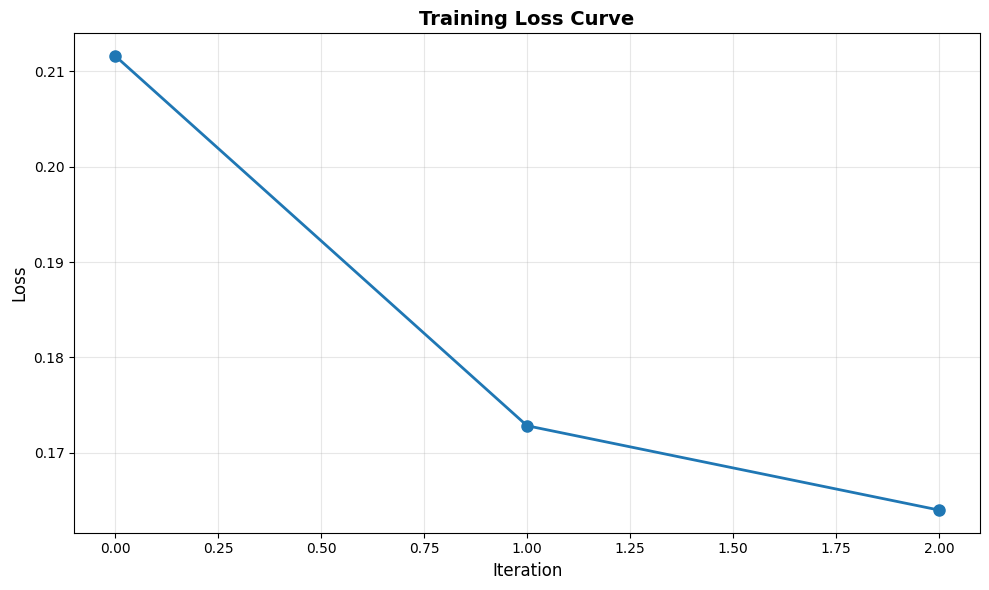


Loss statistics:
  Iterations: 3
  Final loss: 0.163976
  Average loss: 0.182804
  Std loss: 0.020690


In [14]:
# 绘制损失曲线
if len(losses) > 0:
    plt.figure(figsize=(10, 6))
    plt.plot(losses, marker='o', linestyle='-', linewidth=2, markersize=8)
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Training Loss Curve', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nLoss statistics:")
    print(f"  Iterations: {len(losses)}")
    print(f"  Final loss: {losses[-1]:.6f}")
    print(f"  Average loss: {np.mean(losses):.6f}")
    print(f"  Std loss: {np.std(losses):.6f}")
else:
    print("No loss data available. Please run the training loop first.")

## 第九部分：测试视角和评估指标演示

演示如何使用测试视角进行模型评估，包括 PSNR、SSIM、LPIPS 等指标的计算。

In [15]:
# 获取包含测试视角的 batch
# 注意：需要配置 test_image_stride 和 max_test_images 才能生成测试视角
scene_id = dataset.get_current_scene_id()
if scene_id is None:
    print("No scene available. Please check dataset initialization.")
    test_batch = None
else:
    scene_info = dataset.get_scene(scene_id)
    if scene_info and len(scene_info['segments']) > 0:
        segment_id = 0
        
        print(f"Getting batch with test views for scene {scene_id}, segment {segment_id}...")
        print("  (include_test=True will load test frames if available)")
        
        # 获取包含测试视角的 batch
        multi_scene_batch = dataset.get_segment_batch(
            scene_id=scene_id, 
            segment_id=segment_id,
            include_test=True,  # 包含测试视角
        )
        
        print(f"\nBatch structure:")
        print(f"  Scene ID: {multi_scene_batch['scene_id']}")
        print(f"  Segment ID: {multi_scene_batch['segment_id']}")
        print(f"  Source images: {multi_scene_batch['source']['image'].shape}")
        print(f"  Target images: {multi_scene_batch['target']['image'].shape}")
        
        # 检查是否有测试视角
        if 'test' in multi_scene_batch:
            test_data = multi_scene_batch['test']
            print(f"\n  Test views found:")
            print(f"    Test images: {test_data['image'].shape}")
            print(f"    Test extrinsics: {test_data['extrinsics'].shape}")
            print(f"    Test intrinsics: {test_data['intrinsics'].shape}")
            print(f"    Test frame indices: {test_data['frame_indices'].tolist()}")
            print(f"    Test cam indices: {test_data['cam_indices'].tolist()}")
        else:
            print(f"\n  No test views in batch.")
            print(f"    This may happen if:")
            print(f"      - test_image_stride is 0 (all frames used for training)")
            print(f"      - No test frames fall into this segment's frame range")
            print(f"      - max_test_images is 0 or not set")
        
        # 转换 batch 格式
        test_streetforward_batch = convert_batch_to_streetforward_format(
            batch=multi_scene_batch,
            device=device,
        )
        
        print(f"\nStreetForward batch structure:")
        print(f"  Number of target views: {len(test_streetforward_batch['target_views'])}")
        if 'test_views' in test_streetforward_batch and len(test_streetforward_batch['test_views']) > 0:
            print(f"  Number of test views: {len(test_streetforward_batch['test_views'])}")
            print(f"  Number of test images: {len(test_streetforward_batch['test_images'])}")
        else:
            print(f"  Number of test views: 0")
    else:
        print("No segments available in current scene.")
        test_batch = None

Getting batch with test views for scene 8, segment 0...
  (include_test=True will load test frames if available)

Batch structure:
  Scene ID: tensor([8])
  Segment ID: 0
  Source images: torch.Size([9, 300, 533, 3])
  Target images: torch.Size([18, 300, 533, 3])

  Test views found:
    Test images: torch.Size([12, 300, 533, 3])
    Test extrinsics: torch.Size([12, 4, 4])
    Test intrinsics: torch.Size([12, 4, 4])
    Test frame indices: [10, 10, 10, 9, 9, 9, 1, 1, 1, 11, 11, 11]
    Test cam indices: [0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2]

StreetForward batch structure:
  Number of target views: 18
  Number of test views: 12
  Number of test images: 12


In [16]:
# 方法1：使用 train_iter() 的 evaluate_test 参数进行评估
# 这会在训练迭代后自动评估测试视角（如果可用）
if 'test_streetforward_batch' in locals() and test_streetforward_batch is not None:
    if 'test_views' in test_streetforward_batch and len(test_streetforward_batch['test_views']) > 0:
        print("Evaluating test views using train_iter() with evaluate_test=True...")
        
        # 先进行一次训练迭代（可选，用于初始化或更新模型）
        trainer.train()
        outputs = trainer.train_iter(
            batch=test_streetforward_batch,
            apply_update=False,  # 不更新优化器（仅评估）
            update_state=False,  # 不更新 node_state（仅评估）
            evaluate_test=True,  # 启用测试视角评估
        )
        
        # 检查评估结果
        if outputs.get('test_metrics') is not None:
            metrics = outputs['test_metrics']
            print(f"\nTest metrics:")
            print(f"  PSNR: {metrics.get('psnr', 'N/A'):.4f}" if isinstance(metrics.get('psnr'), (int, float)) else f"  PSNR: {metrics.get('psnr', 'N/A')}")
            print(f"  SSIM: {metrics.get('ssim', 'N/A'):.4f}" if isinstance(metrics.get('ssim'), (int, float)) and not np.isnan(metrics.get('ssim')) else f"  SSIM: {metrics.get('ssim', 'N/A')}")
            print(f"  LPIPS: {metrics.get('lpips', 'N/A'):.4f}" if isinstance(metrics.get('lpips'), (int, float)) and not np.isnan(metrics.get('lpips')) else f"  LPIPS: {metrics.get('lpips', 'N/A')}")
            print(f"  Number of test views: {metrics.get('num_test_views', 'N/A')}")
            
            if np.isnan(metrics.get('ssim', np.nan)) or np.isnan(metrics.get('lpips', np.nan)):
                print(f"\n  Note: SSIM/LPIPS may require additional packages:")
                print(f"    - SSIM: pip install pytorch-msssim")
                print(f"    - LPIPS: pip install lpips")
        else:
            print("  No test metrics returned (test views may not be available)")
    else:
        print("No test views available in batch. Skipping evaluation.")
        print("  To enable test views:")
        print("    1. Set test_image_stride > 0 in config (e.g., test_image_stride: 10)")
        print("    2. Set max_test_images > 0 in config (e.g., max_test_images: 4)")
else:
    print("No test batch available. Please run the previous cell first.")

Evaluating test views using train_iter() with evaluate_test=True...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/root/miniconda3/envs/drivestudio-new/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/root/miniconda3/envs/drivestudio-new/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /root/miniconda3/envs/drivestudio-new/lib/python3.9/site-packages/lpips/weights/v0.1/alex.pth

Test metrics:
  PSNR: 7.1069
  SSIM: 0.0369
  LPIPS: 0.7350
  Number of test views: 12


In [17]:
# 方法2：使用独立的 evaluate() 方法进行评估
# 这个方法专门用于评估，不进行训练
if 'test_streetforward_batch' in locals() and test_streetforward_batch is not None:
    if 'test_views' in test_streetforward_batch and len(test_streetforward_batch['test_views']) > 0:
        print("Evaluating test views using evaluate() method...")
        
        # 确保模型处于评估模式
        trainer.eval()
        
        # 使用 evaluate() 方法（不需要梯度）
        with torch.no_grad():
            metrics = trainer.evaluate(batch=test_streetforward_batch)
        
        if metrics:
            print(f"\nEvaluation metrics:")
            print(f"  PSNR: {metrics.get('psnr', 'N/A'):.4f}" if isinstance(metrics.get('psnr'), (int, float)) else f"  PSNR: {metrics.get('psnr', 'N/A')}")
            print(f"  SSIM: {metrics.get('ssim', 'N/A'):.4f}" if isinstance(metrics.get('ssim'), (int, float)) and not np.isnan(metrics.get('ssim')) else f"  SSIM: {metrics.get('ssim', 'N/A')}")
            print(f"  LPIPS: {metrics.get('lpips', 'N/A'):.4f}" if isinstance(metrics.get('lpips'), (int, float)) and not np.isnan(metrics.get('lpips')) else f"  LPIPS: {metrics.get('lpips', 'N/A')}")
            print(f"  Number of test views: {metrics.get('num_test_views', 'N/A')}")
        else:
            print("  No metrics returned")
        
        # 恢复训练模式
        trainer.train()
    else:
        print("No test views available in batch.")
else:
    print("No test batch available. Please run the previous cell first.")

Evaluating test views using evaluate() method...

Evaluation metrics:
  PSNR: 7.1069
  SSIM: 0.0369
  LPIPS: 0.7350
  Number of test views: 12


In [ ]:
# 展示节点状态信息
print("Node states summary:")
print(f"  Total number of nodes: {len(trainer.node_states)}")
print("\nNode details:")

for (scene_id, segment_id), node_state in trainer.node_states.items():
    print(f"\n  Scene {scene_id}, Segment {segment_id}:")
    print(f"    Number of Gaussians: {node_state.means.shape[0]}")
    print(f"    Means range:")
    print(f"      X: [{node_state.means[:, 0].min().item():.2f}, {node_state.means[:, 0].max().item():.2f}]")
    print(f"      Y: [{node_state.means[:, 1].min().item():.2f}, {node_state.means[:, 1].max().item():.2f}]")
    print(f"      Z: [{node_state.means[:, 2].min().item():.2f}, {node_state.means[:, 2].max().item():.2f}]")
    print(f"    Scales log range: [{node_state.scales_log.min().item():.4f}, {node_state.scales_log.max().item():.4f}]")
    print(f"    Opacity logit range: [{node_state.opacity_logit.min().item():.4f}, {node_state.opacity_logit.max().item():.4f}]")

In [19]:
# 可选：可视化点云（如果点云不太大）
# 注意：如果点云很大，可视化可能会很慢
# 可以从 batch 中获取点云，或者从之前生成的 pointcloud_dict 获取

# 方法1：从 batch 中获取点云（如果存在）
if 'streetforward_batch' in locals() and streetforward_batch is not None:
    pointcloud_dict = streetforward_batch.get('pointcloud')
elif 'multi_scene_batch' in locals() and multi_scene_batch is not None:
    pointcloud_dict = multi_scene_batch.get('pointcloud')
elif 'pointcloud_dict' in locals() and pointcloud_dict is not None:
    # 使用之前手动生成的点云
    pass
else:
    pointcloud_dict = None

if pointcloud_dict is not None:
    background_points = pointcloud_dict.get("background", np.zeros((0, 6), dtype=np.float32))
    
    print(f"\nVisualizing point cloud ({len(background_points)} points)...")
    
    # 创建 Open3D 点云对象
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(background_points[:, :3])
    
    # 转换颜色到 [0, 1] 范围（如果原始颜色在 [0, 255] 范围）
    colors = background_points[:, 3:6].copy()
    if colors.max() > 1.0 + 1e-3:
        colors = colors / 255.0
    colors = np.clip(colors, 0.0, 1.0)
    pcd.colors = o3d.utility.Vector3dVector(colors)
    
    # 可视化
    print("  Displaying point cloud...")
    o3d.visualization.draw_geometries([pcd], window_name="Point Cloud Visualization")

else:
    print("\nNo point cloud available for visualization.")
    print("  Tip: Run a cell that creates a batch (get_segment_batch) to get pointcloud in batch.")


Visualizing point cloud (761200 points)...
  Displaying point cloud...
[Open3D WARNING] GLFW Error: X11: The DISPLAY environment variable is missing
[Open3D WARNING] Failed to initialize GLFW
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.
